In [94]:
# NBA Knicks Game-Level Demand Classification

# 1. Import Libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    classification_report
)

pd.set_option("display.max_columns", 500)


In [95]:
# 2. Load Dataset

file_path = "knicks_classification_modeling_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nOriginal columns:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (1168, 15)

Original columns:
['Last Five', 'Capacity', 'Curr Win %', 'LS Win %', 'visitor_allstar_count', 'home_allstar_count', 'season_year', 'Day of Week', 'Month', 'Visitor', 'Playoffs?', 'Rivalry?', 'Attendance', 'occupancy_rate', 'high_demand']


,Last Five,Capacity,Curr Win %,LS Win %,visitor_allstar_count,home_allstar_count,season_year,Day of Week,Month,Visitor,Playoffs?,Rivalry?,Attendance,occupancy_rate,high_demand
0,4,18212,0.480000,0.61039,0,1,1989,Tuesday,January,Phoenix Suns,0,0,18212,1.000000,1
1,4,18212,0.695652,0.61039,1,1,1989,Thursday,January,Atlanta Hawks,0,0,18212,1.000000,1
2,3,18212,0.680000,0.61039,0,1,1989,Sunday,January,Los Angeles Clippers,0,0,17491,0.960411,1
3,3,18212,0.678571,0.61039,1,1,1989,Saturday,January,San Antonio Spurs,0,0,18212,1.000000,1
4,4,18212,0.689655,0.61039,2,1,1989,Monday,January,Chicago Bulls,0,1,18212,1.000000,1


In [96]:
# 3. Rename Columns

df = df.rename(columns={
    "Date": "Game_Date",
    "Start (ET)": "Start_Time_ET",
    "Visitor": "Visitor_Team",
    "Visitor/Neutral": "Visitor_Team",
    "Home/Neutral": "Home_Team",
    "Home": "Home_Team",
    "V PTS": "Visitor_Points",
    "H PTS": "Home_Points",
    "Attendance": "Attendance",
    "Capacity": "Capacity",
    "Arena": "Arena",
    "Notes": "Notes",
    "Season": "Season",
    "season_year": "Season_Year",
    "Month": "Month",
    "Day of Week": "Day_of_Week",
    "Playoffs?": "Playoffs",
    "Rivalry?": "Rivalry",
    "Last Five": "Last_Five_Games",
    "Curr Win %": "Current_Win_Pct",
    "LS Win %": "Previous_Season_Win_Pct",
    "V Pop": "Visitor_Popularity",
    "H Pop": "Home_Popularity",
    "Match-up": "Matchup",
    "visitor_allstar_count": "Visitor_Allstar_Count",
    "home_allstar_count": "Home_Allstar_Count"
})

print("\nRenamed columns:")
print(df.columns.tolist())



Renamed columns:
['Last_Five_Games', 'Capacity', 'Current_Win_Pct', 'Previous_Season_Win_Pct', 'Visitor_Allstar_Count', 'Home_Allstar_Count', 'Season_Year', 'Day_of_Week', 'Month', 'Visitor_Team', 'Playoffs', 'Rivalry', 'Attendance', 'occupancy_rate', 'high_demand']


In [97]:
# 4. Initial Data Inspection

print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

display(df.head())


Dataset shape: (1168, 15)

Missing values:
Last_Five_Games            0
Capacity                   0
Current_Win_Pct            0
Previous_Season_Win_Pct    0
Visitor_Allstar_Count      0
Home_Allstar_Count         0
Season_Year                0
Day_of_Week                0
Month                      0
Visitor_Team               0
Playoffs                   0
Rivalry                    0
Attendance                 0
occupancy_rate             0
high_demand                0
dtype: int64

Data types:
Last_Five_Games              int64
Capacity                     int64
Current_Win_Pct            float64
Previous_Season_Win_Pct    float64
Visitor_Allstar_Count        int64
Home_Allstar_Count           int64
Season_Year                  int64
Day_of_Week                 object
Month                       object
Visitor_Team                object
Playoffs                     int64
Rivalry                      int64
Attendance                   int64
occupancy_rate             float64
high_d

,Last_Five_Games,Capacity,Current_Win_Pct,Previous_Season_Win_Pct,Visitor_Allstar_Count,Home_Allstar_Count,Season_Year,Day_of_Week,Month,Visitor_Team,Playoffs,Rivalry,Attendance,occupancy_rate,high_demand
0,4,18212,0.480000,0.61039,0,1,1989,Tuesday,January,Phoenix Suns,0,0,18212,1.000000,1
1,4,18212,0.695652,0.61039,1,1,1989,Thursday,January,Atlanta Hawks,0,0,18212,1.000000,1
2,3,18212,0.680000,0.61039,0,1,1989,Sunday,January,Los Angeles Clippers,0,0,17491,0.960411,1
3,3,18212,0.678571,0.61039,1,1,1989,Saturday,January,San Antonio Spurs,0,0,18212,1.000000,1
4,4,18212,0.689655,0.61039,2,1,1989,Monday,January,Chicago Bulls,0,1,18212,1.000000,1


In [98]:
# 5. Feature Engineering

# Weekend games may have different attendance behavior because
# fans are generally more available on Saturdays and Sundays.

df["Weekend"] = df["Day_of_Week"].isin(["Saturday", "Sunday"]).astype(int)


In [123]:
# 6. Target Variable Creation-

# The demand threshold is calculated using only the training-period
# seasons (<=2014). This threshold is then applied across the full
# dataset to create the High_Demand label.
train_mask = df["Season_Year"] <= 2014
attendance_cutoff = df.loc[train_mask, "Attendance"].quantile(0.90)

df["High_Demand"] = np.where(
    df["Attendance"] >= attendance_cutoff,
    1,
    0
)

print("High-demand attendance cutoff:", attendance_cutoff)
print(df["High_Demand"].value_counts())
print((df["High_Demand"].value_counts(normalize=True) * 100).round(2))

High-demand attendance cutoff: 19763.0
High_Demand
1    855
0    313
Name: count, dtype: int64
High_Demand
1    73.2
0    26.8
Name: proportion, dtype: float64


In [100]:
# 7. Time-Based Train/Test Split

# Since this is historical sports data, a time-based split is more
# realistic than a random split. The model trains on older seasons
# and tests on later seasons.

train_df = df[df["Season_Year"] <= 2014].copy()
test_df = df[df["Season_Year"] >= 2015].copy()

print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

Training data shape: (992, 17)
Testing data shape: (176, 17)


In [101]:
# 8. Feature Selection

numeric_features = [
    "Last_Five_Games",
    "Capacity",
    "Current_Win_Pct",
    "Previous_Season_Win_Pct",
    "Visitor_Allstar_Count",
    "Home_Allstar_Count"
]

In [102]:
# 9. Categorical features capture schedule timing and opponent identity.

categorical_features = [
    "Day_of_Week",
    "Month",
    "Visitor_Team"
]

# Binary features capture special game conditions.

binary_features = [
    "Playoffs",
    "Rivalry",
    "Weekend"
]

target = "High_Demand"



In [103]:
# 10. Binary Feature Conversion


for col in binary_features:
    if train_df[col].dtype == "object":
        train_df[col] = train_df[col].map({
            "Yes": 1,
            "No": 0,
            "True": 1,
            "False": 0,
            True: 1,
            False: 0
        })

        test_df[col] = test_df[col].map({
            "Yes": 1,
            "No": 0,
            "True": 1,
            "False": 0,
            True: 1,
            False: 0
        })

    train_df[col] = train_df[col].astype(int)
    test_df[col] = test_df[col].astype(int)


In [104]:
# 10. Create Modeling Dataset

X_train = train_df[numeric_features + categorical_features + binary_features]
y_train = train_df[target]

X_test = test_df[numeric_features + categorical_features + binary_features]
y_test = test_df[target]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

print("\nTrain target balance:")
print(y_train.value_counts())

print("\nTest target balance:")
print(y_test.value_counts())

Train size: (992, 12)
Test size: (176, 12)

Train target balance:
High_Demand
1    735
0    257
Name: count, dtype: int64

Test target balance:
High_Demand
1    120
0     56
Name: count, dtype: int64


In [105]:
# 12. Preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("bin", "passthrough", binary_features)
    ]
)

In [106]:
# 13. Model Setup

# Four classification models are tested:
# 1. Logistic Regression
# 2. K-Nearest Neighbors
# 3. Decision Tree
# 4. Random Forest


logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(
        n_neighbors=11
    ))
])

decision_tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=4,
        class_weight="balanced",
        random_state=42
    ))
])

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ))
])

adaboost_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", AdaBoostClassifier(
        random_state=42
    ))
])
models = {
    "Logistic Regression": logistic_model,
    "KNN k=11": knn_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "AdaBoost": adaboost_model
}



In [107]:
# 14. Model Comparison


# This function trains each model and evaluates it on the test set.
# Multiple metrics are used because accuracy alone can be misleading
# for imbalanced classification problems.

def evaluate_model(model_name, model):
    """
    Train a classification model and return evaluation metrics,
    class predictions, and predicted probabilities.
    """

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "PR_AUC": average_precision_score(y_test, y_prob)
    }, y_pred, y_prob


results_list = []
predictions = {}
probabilities = {}

for model_name, model in models.items():
    result, y_pred, y_prob = evaluate_model(model_name, model)

    results_list.append(result)
    predictions[model_name] = y_pred
    probabilities[model_name] = y_prob

results_df = pd.DataFrame(results_list).sort_values(
    by="ROC_AUC",
    ascending=False
)

display(results_df)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
4,AdaBoost,0.653409,0.765766,0.708333,0.735931,0.661310,0.813283
3,Random Forest,0.556818,0.738636,0.541667,0.625000,0.598810,0.740085
1,KNN k=11,0.619318,0.715447,0.733333,0.724280,0.573735,0.725262
2,Decision Tree,0.318182,0.000000,0.000000,0.000000,0.522024,0.691590
0,Logistic Regression,0.409091,0.681818,0.250000,0.365854,0.512649,0.704243


In [122]:
# 15. Select Best Model

# AdaBoost is selected as the final model because it produced the
# strongest overall performance in the model comparison.

best_model_name = "AdaBoost"
best_model = models[best_model_name]

print("Selected Best Model:", best_model_name)

Selected Best Model: AdaBoost


In [109]:
# 16. Threshold Tuning

# The default classification threshold is 0.50.

best_model.fit(X_train, y_train)

best_model_probs = best_model.predict_proba(X_test)[:, 1]

thresholds = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.40,
    0.50
]

threshold_results = []

for threshold in thresholds:
    threshold_preds = (best_model_probs >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, threshold_preds, zero_division=0),
        "Recall": recall_score(y_test, threshold_preds, zero_division=0),
        "F1": f1_score(y_test, threshold_preds, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df)

,Threshold,Precision,Recall,F1
0,0.05,0.681818,1.000000,0.810811
1,0.10,0.681818,1.000000,0.810811
2,0.15,0.681818,1.000000,0.810811
3,0.20,0.681818,1.000000,0.810811
4,0.25,0.681818,1.000000,0.810811
5,0.30,0.681818,1.000000,0.810811
6,0.40,0.681818,1.000000,0.810811
7,0.50,0.765766,0.708333,0.735931


In [110]:
# 17. Final Model Evaluation

best_threshold = 0.50

final_preds = (best_model_probs >= best_threshold).astype(int)

print("Final Model:", best_model_name)
print("Selected Threshold:", best_threshold)

print("\nClassification Report:")
print(classification_report(y_test, final_preds, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_preds))

Final Model: AdaBoost
Selected Threshold: 0.5

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.54      0.50        56
           1       0.77      0.71      0.74       120

    accuracy                           0.65       176
   macro avg       0.61      0.62      0.62       176
weighted avg       0.67      0.65      0.66       176


Confusion Matrix:
[[30 26]
 [35 85]]


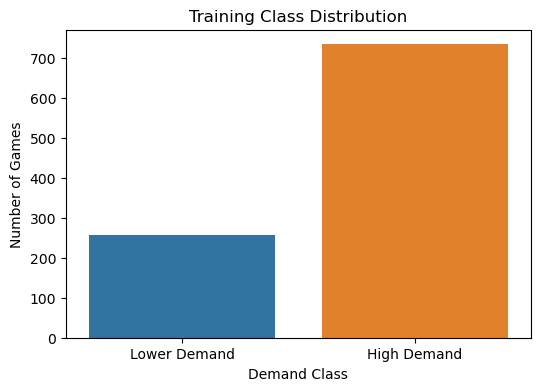

In [111]:
# 18. Model Visualizations

# 18.1 Training Class Distribution

# Visualize the balance between high-demand and lower-demand games
# in the training dataset.

plt.figure(figsize=(6, 4))

sns.countplot(
    data=train_df,
    x="High_Demand"
)

plt.title("Training Class Distribution")
plt.xlabel("Demand Class")
plt.ylabel("Number of Games")

plt.xticks(
    [0, 1],
    ["Lower Demand", "High Demand"]
)

plt.show()

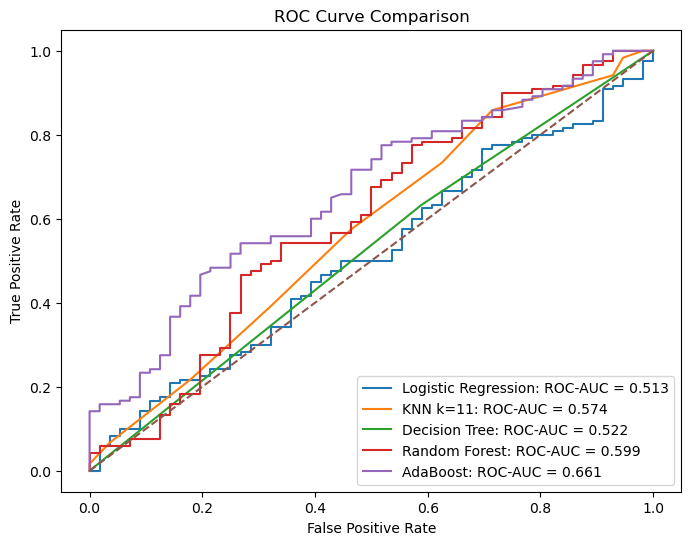

In [112]:
# 18.2 ROC Curve Comparison

# ROC curves compare model performance across all classification
# thresholds.

plt.figure(figsize=(8, 6))

for model_name in models.keys():

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities[model_name]
    )

    auc_score = roc_auc_score(
        y_test,
        probabilities[model_name]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name}: ROC-AUC = {auc_score:.3f}"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

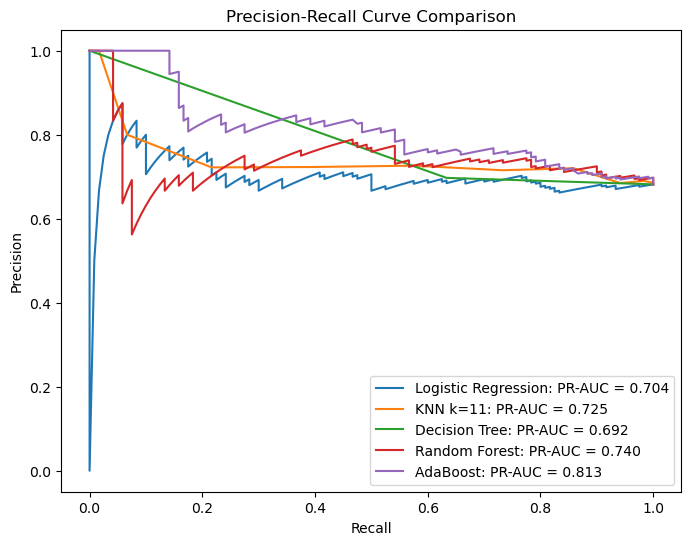

In [113]:
# 18.3 Precision-Recall Curve Comparison

plt.figure(figsize=(8, 6))

for model_name in models.keys():

    precision, recall, _ = precision_recall_curve(
        y_test,
        probabilities[model_name]
    )

    pr_auc = average_precision_score(
        y_test,
        probabilities[model_name]
    )

    plt.plot(
        recall,
        precision,
        label=f"{model_name}: PR-AUC = {pr_auc:.3f}"
    )

plt.title("Precision-Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

plt.show()


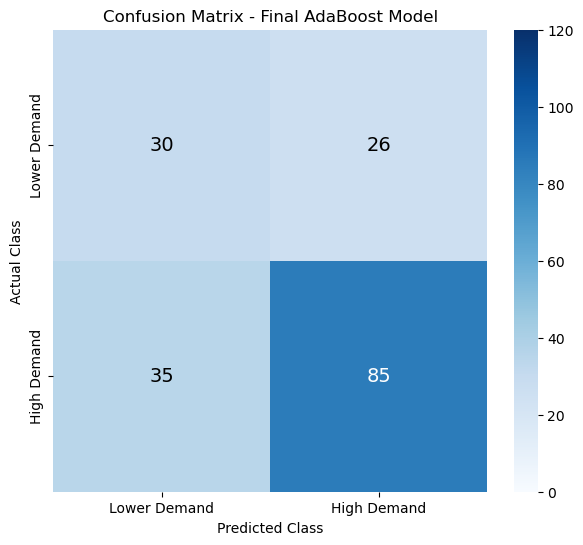

In [114]:
# -----------------------------
# Confusion Matrix Plot
# -----------------------------

cm = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=False,
    fmt="d",
    cmap="Blues",
    vmin=0,
    vmax=120,
    cbar=True,
    xticklabels=["Lower Demand", "High Demand"],
    yticklabels=["Lower Demand", "High Demand"]
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j + 0.5,
            i + 0.5,
            cm[i, j],
            ha="center",
            va="center",
            color="white" if cm[i, j] > 60 else "black",
            fontsize=14
        )

plt.title("Confusion Matrix - Final AdaBoost Model")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [115]:
cm

array([[30, 26],
       [35, 85]], dtype=int64)

In [116]:
# 18.5 Lift Analysis

lift_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted_Probability": best_model_probs
})

lift_df = (
    lift_df
    .sort_values(
        by="Predicted_Probability",
        ascending=False
    )
    .reset_index(drop=True)
)

lift_df["Rank"] = np.arange(
    1,
    len(lift_df) + 1
)

lift_df["Decile"] = pd.qcut(
    lift_df["Rank"],
    10,
    labels=False
) + 1

overall_rate = (
    lift_df["Actual"]
    .mean()
)

lift_chart_data = (
    lift_df
    .groupby("Decile")
    .agg(
        Games=("Actual", "count"),
        High_Demand=("Actual", "sum")
    )
    .reset_index()
)

lift_chart_data["Response_Rate"] = (
    lift_chart_data["High_Demand"] /
    lift_chart_data["Games"]
)

lift_chart_data["Lift"] = (
    lift_chart_data["Response_Rate"] /
    overall_rate
)

display(lift_chart_data)

,Decile,Games,High_Demand,Response_Rate,Lift
0,1,18,17,0.944444,1.385185
1,2,18,12,0.666667,0.977778
2,3,17,15,0.882353,1.294118
3,4,18,14,0.777778,1.140741
4,5,17,9,0.529412,0.776471
5,6,18,13,0.722222,1.059259
6,7,17,13,0.764706,1.121569
7,8,18,8,0.444444,0.651852
8,9,17,9,0.529412,0.776471
9,10,18,10,0.555556,0.814815


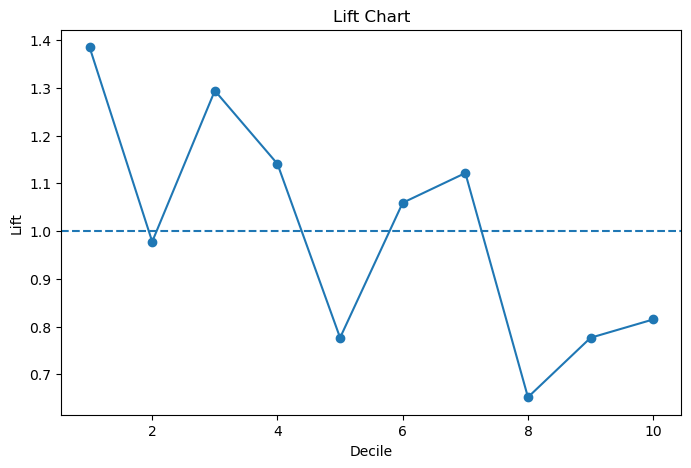

In [117]:
# 18.6 Lift Chart Visualization

plt.figure(figsize=(8, 5))

plt.plot(
    lift_chart_data["Decile"],
    lift_chart_data["Lift"],
    marker="o"
)

plt.axhline(
    y=1,
    linestyle="--"
)

plt.title("Lift Chart")
plt.xlabel("Decile")
plt.ylabel("Lift")

plt.show()

In [118]:
# 18.7 Cumulative Lift Analysis

lift_chart_data["Cumulative_Games"] = (
    lift_chart_data["Games"]
    .cumsum()
)

lift_chart_data["Cumulative_High_Demand"] = (
    lift_chart_data["High_Demand"]
    .cumsum()
)

lift_chart_data["Cumulative_Response_Rate"] = (
    lift_chart_data["Cumulative_High_Demand"] /
    lift_chart_data["Cumulative_Games"]
)

lift_chart_data["Cumulative_Lift"] = (
    lift_chart_data["Cumulative_Response_Rate"] /
    overall_rate
)

display(lift_chart_data)

,Decile,Games,High_Demand,Response_Rate,Lift,Cumulative_Games,Cumulative_High_Demand,Cumulative_Response_Rate,Cumulative_Lift
0,1,18,17,0.944444,1.385185,18,17,0.944444,1.385185
1,2,18,12,0.666667,0.977778,36,29,0.805556,1.181481
2,3,17,15,0.882353,1.294118,53,44,0.830189,1.217610
3,4,18,14,0.777778,1.140741,71,58,0.816901,1.198122
4,5,17,9,0.529412,0.776471,88,67,0.761364,1.116667
5,6,18,13,0.722222,1.059259,106,80,0.754717,1.106918
6,7,17,13,0.764706,1.121569,123,93,0.756098,1.108943
7,8,18,8,0.444444,0.651852,141,101,0.716312,1.050591
8,9,17,9,0.529412,0.776471,158,110,0.696203,1.021097
9,10,18,10,0.555556,0.814815,176,120,0.681818,1.000000


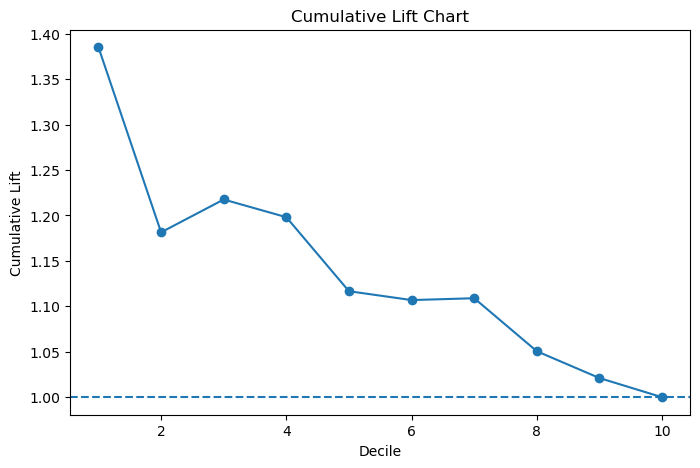

In [119]:
# 18.8 Cumulative Lift Visualization

plt.figure(figsize=(8, 5))

plt.plot(
    lift_chart_data["Decile"],
    lift_chart_data["Cumulative_Lift"],
    marker="o"
)

plt.axhline(
    y=1,
    linestyle="--"
)

plt.title("Cumulative Lift Chart")
plt.xlabel("Decile")
plt.ylabel("Cumulative Lift")

plt.show()


In [120]:
# 18.9 Feature Importance

rf_model = best_model.named_steps["model"]

encoded_cat_features = (
    best_model
    .named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
)

all_feature_names = (
    numeric_features +
    list(encoded_cat_features) +
    binary_features
)
# Create feature importance dataframe
feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": rf_model.feature_importances_
})
# Sort features by importance
feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(feature_importance_df.head(15))

,Feature,Importance
0,Previous_Season_Win_Pct,0.28
1,Current_Win_Pct,0.12
2,Visitor_Allstar_Count,0.06
3,Capacity,0.06
4,Last_Five_Games,0.04
5,Month_January,0.04
6,Home_Allstar_Count,0.04
7,Visitor_Team_Indiana Pacers,0.04
8,Rivalry,0.04
9,Month_November,0.04


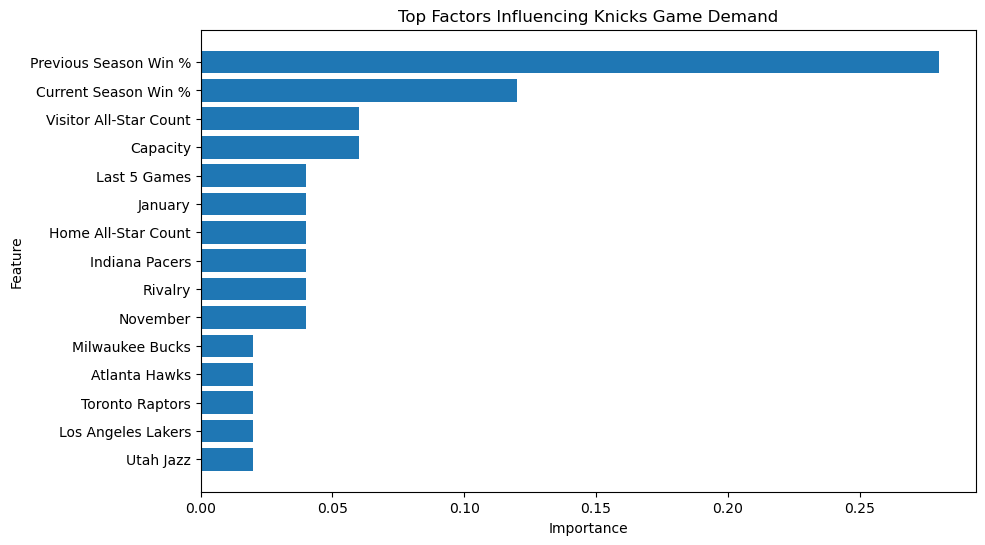

In [121]:
# 18.10 Feature Importance Plot

# Select top 15 features
top_features = feature_importance_df.head(15).copy()

# Rename features only for presentation in the chart
top_features["Feature"] = top_features["Feature"].replace({
    "Previous_Season_Win_Pct": "Previous Season Win %",
    "Current_Win_Pct": "Current Season Win %",
    "Visitor_Allstar_Count": "Visitor All-Star Count",
    "Home_Allstar_Count": "Home All-Star Count",
    "Last_Five_Games": "Last 5 Games",
    "Month_January": "January",
    "Month_November": "November",
    "Visitor_Team_Indiana Pacers": "Indiana Pacers",
    "Visitor_Team_Milwaukee Bucks": "Milwaukee Bucks",
    "Visitor_Team_Atlanta Hawks": "Atlanta Hawks",
    "Visitor_Team_Toronto Raptors": "Toronto Raptors",
    "Visitor_Team_Los Angeles Lakers": "Los Angeles Lakers",
    "Visitor_Team_Utah Jazz": "Utah Jazz"
})

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top Factors Influencing Knicks Game Demand")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

